In [1]:
# Load necessary libraries
suppressMessages(library(DESeq2))
suppressMessages(library(ggplot2))
suppressMessages(library(latex2exp))
suppressMessages(library(pROC))
suppressMessages(library(data.table))
suppressMessages(library(glmnet))
suppressMessages(library(corrplot))
suppressMessages(library(caret))

In [11]:
data <- read.csv("/home/bdkhoi/projects/transcriptomics_classifier/work/1e/53959cd024490d5574f58c8cd6e256/train_merged_count.csv", row.names = 1)
meta <- read.csv("/home/bdkhoi/projects/transcriptomics_classifier/data/112_samples/clean_design.csv", row.names=1)
head(meta)

,group,fastq_1,fastq_2,strandedness
,<chr>,<chr>,<chr>,<chr>
HPV16_1,cancer,s3://pacinfo-fs/tmp/cduong/RNAseq/SRR11908726.fastq.gz,,auto
HPV18_1,cancer,s3://pacinfo-fs/tmp/cduong/RNAseq/SRR11908727.fastq.gz,,auto
HPV16_2,cancer,s3://pacinfo-fs/tmp/cduong/RNAseq/SRR11908728.fastq.gz,,auto
HPV16_3,cancer,s3://pacinfo-fs/tmp/cduong/RNAseq/SRR11908729.fastq.gz,,auto
nd_11,cancer,s3://pacinfo-fs/tmp/cduong/RNAseq/SRR11908730.fastq.gz,,auto
HPV16_4,cancer,s3://pacinfo-fs/tmp/cduong/RNAseq/SRR11908731.fastq.gz,,auto


In [12]:
pca_data <- data
t_pca_data <- t(pca_data)
print(sum(is.na(t_pca_data)))

[1] 0


In [13]:
pca_result <- prcomp(t_pca_data)
summary(pca_result)

Importance of components:
                             PC1       PC2       PC3       PC4       PC5
Standard deviation     1.139e+06 6.080e+05 2.925e+05 2.402e+05 1.919e+05
Proportion of Variance 6.423e-01 1.830e-01 4.237e-02 2.856e-02 1.823e-02
Cumulative Proportion  6.423e-01 8.254e-01 8.677e-01 8.963e-01 9.145e-01
                             PC6       PC7       PC8       PC9      PC10
Standard deviation     1.803e+05 1.515e+05 1.388e+05 1.123e+05 9.386e+04
Proportion of Variance 1.610e-02 1.136e-02 9.540e-03 6.240e-03 4.360e-03
Cumulative Proportion  9.306e-01 9.420e-01 9.515e-01 9.578e-01 9.621e-01
                            PC11      PC12      PC13      PC14      PC15
Standard deviation     8.712e+04 8.044e+04 7.726e+04 6.766e+04 6.349e+04
Proportion of Variance 3.760e-03 3.200e-03 2.960e-03 2.270e-03 2.000e-03
Cumulative Proportion  9.659e-01 9.691e-01 9.720e-01 9.743e-01 9.763e-01
                            PC16      PC17      PC18      PC19      PC20
Standard deviation     6.

In [15]:
meta$group <- as.factor(meta$group)
meta <- meta[colnames(data), , drop = FALSE]

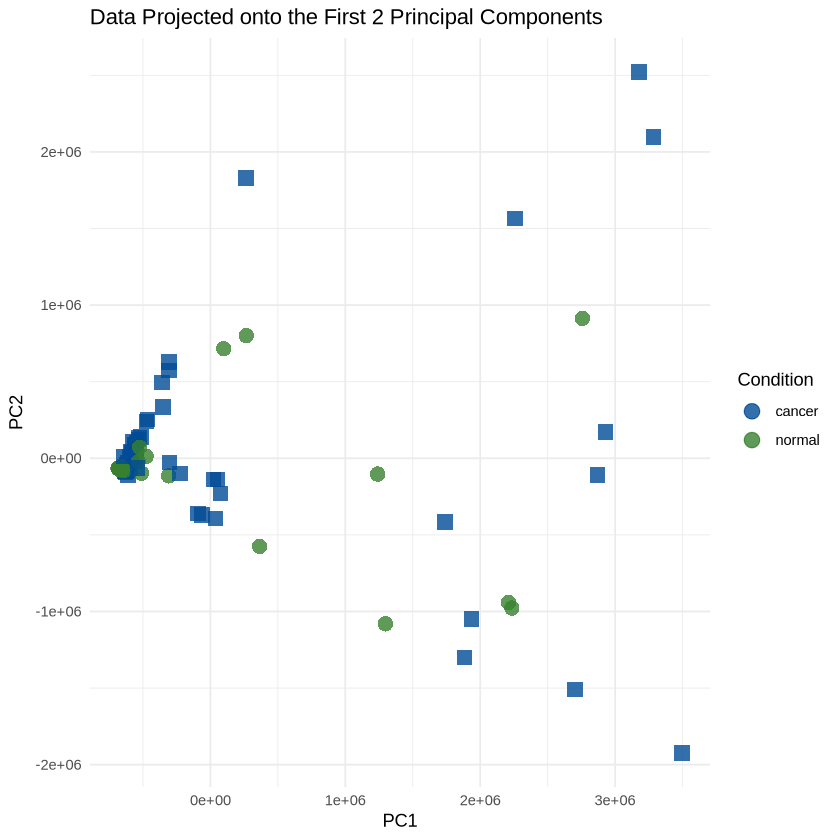

In [16]:
first_two_components <- data.frame(pca_result$x[, 1:2], Condition = meta$group)
colors <- c(
  "#004B95", "#38812F", "#A30000", "#FF8C00", "#9400D3", "#228B22", 
  "#DC143C", "#FFD700", "#8B008B", "#00CED1", "#FF4500", "#556B2F"
)
shapes <- c(15, 16, 17, 18, 19, 7, 8, 10, 12, 13, 14, 3)

ggplot(first_two_components, aes(x = PC1, y = PC2, color = Condition)) +
  geom_point(alpha = 0.8, size = 4, shape = shapes[as.numeric(first_two_components$Condition)]) +
  labs(title = "Data Projected onto the First 2 Principal Components") +
  scale_color_manual(values = colors) +
  theme_minimal()

In [6]:
data_human <- read.csv("/home/bdkhoi/projects/transcriptomics_classifier/data/112_samples/human/merged_gene_counts_human.csv", sep=",", row.names = 1)
data_viral <- read.csv("/home/bdkhoi/projects/transcriptomics_classifier/data/112_samples/viral/merged_gene_counts_viral.csv", sep=",", row.names = 1)

In [8]:
data_human["gene_name"] <- NULL
data_viral["gene_name"] <- NULL

In [12]:
design <- read.csv("/home/bdkhoi/projects/transcriptomics_classifier/data/112_samples/design_112.csv", sep=",", row.names="sample")

In [53]:
data_viral <- data_viral[, colnames(data_viral) != "normal_18", drop=FALSE]
data_human <- data_human[, colnames(data_human) != "normal_18", drop=FALSE]
design <- design[rownames(design) != "normal_18", , drop=FALSE]

In [61]:
rownames(design)

[1] "HPV16_1"   "HPV18_1"   "HPV16_2"   "HPV16_3"   "nd_11"     "HPV16_4"  
  [7] "HPV16_5"   "HPV58_1"   "HPV16_6"   "HPV52_1"   "HPV16_7"   "HPV33_1"  
 [13] "HPV18_2"   "HPV16_8"   "HPV18_3"   "HPV16_9"   "HPV16_10"  "nd_12"    
 [19] "HPV59_1"   "HPV33_2"   "HPV16_11"  "nd_13"     "HPV45_1"   "HPV16_12" 
 [25] "HPV59_2"   "HPV16_13"  "HPV16_14"  "HPV16_15"  "nd_14"     "nd_15"    
 [31] "nd_16"     "HPV16_16"  "HPV16_17"  "HPV16_18"  "HPV16_19"  "HPV16_20" 
 [37] "HPV16_21"  "HPV16_22"  "HPV16_23"  "HPV18_4"   "HPV18_5"   "HPV16_24" 
 [43] "HPV16_25"  "HPV16_26"  "HPV16_27"  "HPV16_28"  "HPV18_6"   "HPV16_29" 
 [49] "HPV33_3"   "HPV33_4"   "HPV16_30"  "HPV16_31"  "HPV16_32"  "HPV16_33" 
 [55] "HPV16_34"  "HPV16_35"  "HPV16_36"  "HPV16_37"  "HPV16_38"  "HPV16_39" 
 [61] "HPV16_40"  "HPV16_41"  "HPV16_42"  "HPV16_43"  "HPV16_44"  "HPV16_45" 
 [67] "HPV16_46"  "HPV16_47"  "normal_1"  "normal_2"  "normal_3"  "normal_4" 
 [73] "normal_5"  "normal_6"  "normal_7"  "normal_8"  "normal_9"  "normal_10"
 [79] "normal_11" "normal_12" "normal_13" "normal_14" "normal_15" "normal_16"
 [85] "normal_17" "normal_19" "normal_20" "normal_21" "normal_22" "normal_23"
 [91] "normal_24" "normal_25" "normal_26" "normal_27" "normal_28" "normal_29"
 [97] "normal_30" "normal_31" "normal_32" "normal_33" "normal_34" "normal_35"
[103] "nd_1"      "nd_2"      "nd_3"      "nd_4"      "nd_5"      "nd_6"     
[109] "nd_7"      "nd_8"      "nd_9"

In [63]:
write.csv(data_viral[, rownames(design), drop = FALSE], "/home/bdkhoi/projects/transcriptomics_classifier/data/112_samples/clean_viral_counts.csv", row.names=TRUE)
write.csv(data_human[, rownames(design), drop = FALSE], "/home/bdkhoi/projects/transcriptomics_classifier/data/112_samples/clean_human_counts.csv", row.names=TRUE)
write.csv(design, "/home/bdkhoi/projects/transcriptomics_classifier/data/112_samples/clean_design.csv", row.names=TRUE)

In [52]:
write.csv(data_viral[, colnames(data_viral) != "normal_18", drop=FALSE], "data/112_samples/clean_viral_counts.csv", row.names = TRUE)
write.csv(data_[, colnames(data_viral) != "normal_18", drop=FALSE], "data/112_samples/clean_human_counts.csv", row.names = TRUE)

,normal_3,HPV16_6,HPV18_3,HPV16_20,HPV16_28,HPV16_5,HPV33_2,HPV18_2,HPV16_24,nd_13,⋯,nd_4,normal_7,normal_33,nd_6,nd_7,HPV16_40,HPV16_39,normal_6,HPV16_36,HPV16_37
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
JEMAKDHI_00004,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
JEMAKDHI_00008,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
JEMAKDHI_00010,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
JEMAKDHI_00012,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
JEMAKDHI_00014,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
JEMAKDHI_00016,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
JEMAKDHI_00018,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
JEMAKDHI_00020,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
JEMAKDHI_00022,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [16]:
data_human <- data_human[, rownames(design), drop=FALSE]
data_viral <- data_viral[, rownames(design), drop=FALSE]

ERROR: Error in `[.data.frame`(data_viral, , rownames(design), drop = FALSE): undefined columns selected


In [34]:
exp_ <- read.csv("data/GSE152004_695_expr_norm.txt", sep="\t")
raw <- read.csv("data/GSE152004_695_raw_counts.txt", sep="\t")

In [23]:
write.csv(exp_, "data/GSE152004_normalized.csv")
write.csv(raw, "data/GSE152004_raw.csv")

In [48]:
meta <- read.csv("data/meta.csv", row.names=1)
metadata <- read.csv("data/metadata.csv", row.names=1)
head(metadata)

,characteristics_ch1
,<chr>
HR1005,asthma
HR1006,asthma
HR1009,asthma
HR1010,asthma
HR1012,asthma
HR1016,asthma


In [53]:
combined_meta <- merge(meta, metadata, by.x=0, by.y=0)
rownames(combined_meta) <- combined_meta[, 1]
combined_meta <- combined_meta[, -1]
combined_meta <- combined_meta[colnames(raw), , drop=FALSE]

In [55]:
write.csv(combined_meta, "data/condition_GSE152004.csv")

In [56]:
# Clear the workspace
rm(list = ls())

# Load raw count and normalized count data
cts <- as.matrix(read.csv("data/GSE152004_raw.csv"))
rownames(cts) <- cts[,1]
cts <- cts[,-1]
mode(cts) <- "numeric"

cts_normalized <- as.matrix(read.csv("data/GSE152004_normalized.csv"))
rownames(cts_normalized) <- cts_normalized[,1]
cts_normalized <- cts_normalized[,-1]
mode(cts_normalized) <- "numeric"

# Set seed for reproducibility
set.seed(461)

# Split data into training and testing sets
sample_test <- sample(colnames(cts), 0.2 * ncol(cts))
sample_train <- setdiff(colnames(cts), sample_test)
cts_test <- cts[, sample_test]
cts_train <- cts[, sample_train]
cts_test_normalized <- cts_normalized[, sample_test]
cts_train_normalized <- cts_normalized[, sample_train]

In [72]:
sum(is.na(colnames(cts_train)))

[1] 0

In [57]:
# Load sample condition metadata
coldata <- read.csv("data/condition_GSE152004.csv", row.names=1)
Y_train <- coldata[sample_train,]
Y_test <- coldata[sample_test,]

In [82]:
coldata$Condition <- factor(coldata$Condition)
coldata_train <- coldata[sample_train, 'Condition',drop=FALSE]
coldata_test <- coldata[sample_test, 'Condition',drop=FALSE]
colnames(coldata_train) <- colnames(coldata_test) <- "condition"

# Ensure data consistency
stopifnot(all(rownames(coldata_train) %in% colnames(cts_train)))
stopifnot(all(rownames(coldata_train) == colnames(cts_train)))

In [84]:
# Create DESeq2 dataset and perform differential expression analysis
dds <- DESeqDataSetFromMatrix(countData = cts_train,
                              colData = coldata_train,
                              design = ~ condition)

dds <- dds[rowSums(counts(dds)) >= 10,]
dds <- DESeq(dds)
res <- results(dds)
res <- res[order(res$log2FoldChange),]

# Save results
write.csv(res, "DESeq_results.csv")

converting counts to integer mode

  it appears that the last variable in the design formula, 'condition',
  has a factor level, 'control', which is not the reference level. we recommend
  to use factor(...,levels=...) or relevel() to set this as the reference level
  before proceeding. for more information, please see the 'Note on factor levels'
  in vignette('DESeq2').

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 358 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [85]:
# Generate Volcano plot
jpeg("volcano_plot.jpg", units="in", width=5, height=5, res=300)
with(res, plot(log2FoldChange, -log10(pvalue), pch=20, 
               main="Volcano Plot", xlim=c(-1.5,1.5), ylim=c(0,9), cex=0.1,
               ylab=TeX("-log_{10}(adjusted p-value)"), 
               xlab=TeX("log_{2}(Fold Change)")))
with(subset(res, padj < 0.05), points(log2FoldChange, -log10(pvalue), 
                                      pch=20, col="blue", cex=0.38))
dev.off()

pdf 
  2

In [86]:
# Generate MA plot
jpeg("MA_plot.jpg", units="in", width=5, height=5, res=300)
plotMA(res, ylim=c(-1.5,1.5), alpha=0.05, main="MA Plot", cex=0.38,
       ylab=TeX("log_{2}(Fold Change)"))
dev.off()

pdf 
  2

In [93]:
Y_train$Male <- as.numeric(as.factor(Y_train$Male)) - 1
Y_train$Condition <- as.numeric(as.factor(Y_train$Condition)) - 1
head(Y_train)

,age,Male,Condition
,<dbl>,<dbl>,<dbl>
HR1184,15.50,0,0
HR1186,12.03,0,0
HR1188,13.12,0,0
HR1191,10.75,0,0
HR1192,11.50,0,0
HR1227,14.51,1,0


In [121]:
Y_train <- Y_train[, "Condition", drop=FALSE]
Y_test <- Y_test[, "Condition", drop=FALSE]
head(Y_train)

,Condition
,<dbl>
HR1184,0
HR1186,0
HR1188,0
HR1191,0
HR1192,0
HR1227,0


In [125]:
Y_test$Condition <- as.numeric(as.factor(Y_test$Condition)) - 1

In [114]:
glmnet(as.matrix(data), Y_train$Condition, family="binomial", lambda=0.01)


Call:  glmnet(x = as.matrix(data), y = Y_train$Condition, family = "binomial",      lambda = 0.01) 

   Df  %Dev Lambda
1 295 83.25   0.01

In [106]:
data <- log(t(cts_train_normalized)[, rownames(res)] + 1) 

In [145]:
# LASSO logistic regression for feature selection
lam.vec <- seq(0.01, 0.05, 0.001)
n.lam <- length(lam.vec)
auc <- numeric(n.lam)
mcc <- numeric(n.lam)
acc <- numeric(n.lam)

for(j in seq_along(lam.vec)) {
  fit_lasso <- glmnet(log(t(cts_train_normalized)[, rownames(res)] + 1), 
                      Y_train$Condition, family="binomial", lambda=lam.vec[j])
  Y_hat <- predict(fit_lasso, log(t(cts_test_normalized)[, rownames(res)] + 1), 
                   type="response", lambda=lam.vec[j])
  Y_pred <- as.numeric(Y_hat > 0.5)
  m <- pROC::roc(Y_test$Condition, as.vector(Y_hat), quiet = TRUE)
  auc[j] <- as.numeric(m$auc)
  cm <- confusionMatrix(factor(Y_pred), factor(Y_test$Condition))
  acc[j] <- cm$overall["Accuracy"]
  mcc[j] <- cm$byClass["Matthews Correlation Coefficient"]
}

In [148]:
auc

[1] 0.6370370 0.6389978 0.6407407 0.6420479 0.6444444 0.6435730 0.6448802
 [8] 0.6461874 0.6477124 0.6474946 0.6477124 0.6498911 0.6492375 0.6494553
[15] 0.6511983 0.6520697 0.6527233 0.6520697 0.6533769 0.6509804 0.6509804
[22] 0.6501089 0.6496732 0.6485839 0.6481481 0.6477124 0.6477124 0.6483660
[29] 0.6448802 0.6442266 0.6435730 0.6411765 0.6403050 0.6381264 0.6363834
[36] 0.6333333 0.6302832 0.6276688 0.6274510 0.6257081 0.6246187

In [147]:
best_lambda <- lam.vec[which.max(acc)]
best_lambda

[1] 0.019

In [150]:
# Select best lambda based on accuracy
fit_lasso <- glmnet(log(t(cts_train_normalized)[, rownames(res)] + 1), 
                    Y_train$Condition, family="binomial", lambda=best_lambda)

# Save predicted values
Y_hat_FC <- predict(fit_lasso, log(t(cts_test_normalized)[, rownames(res)] + 1),
                    s=best_lambda)
save(Y_hat_FC, file="Y_hat_FC.RData")


In [131]:
# Generate correlation heatmap
cor_data <- cor(log(t(cts_train_normalized[rownames(res), ]) + 1))
jpeg("correlation_heatmap.jpg", units="in", width=7, height=7, res=300)
corrplot(cor_data, method="color", tl.col="black", tl.srt=63, tl.cex=0.52)
dev.off()

In [140]:
nonzero_idx <- which(coef(fit_lasso) != 0)
write.csv(rownames(coef(fit_lasso))[nonzero_idx], "signatures.csv", row.names = FALSE)

In [153]:
Y_pred_final <- as.numeric(Y_hat_FC > 0.5)
m_final <- pROC::roc(Y_test$Condition, as.vector(Y_hat_FC), quiet = TRUE)
final_auc <- as.numeric(m_final$auc)
cm_final <- confusionMatrix(factor(Y_pred_final), factor(Y_test$Condition))
final_accuracy <- cm_final$overall["Accuracy"]
print(paste("Final Accuracy:", round(final_accuracy, 4)))
print(paste("Final AUC:", round(final_auc, 4)))

[1] "Final Accuracy: 0.6403"


[1] "Final AUC: 0.6475"
